In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("database_gEIN.csv")

def strip_units(x):
    if isinstance(x, str):
        x = x.replace("pS", "").replace("nS", "").replace("uS", "")
        x = x.replace("mV", "").replace("ms", "")
        x = x.replace(" ", "")
        try:
            return float(x)
        except:
            return np.nan
    return x

for col in ["coh","gEIN","dt", "dt1", "dt2", "peak1", "peak2"]:
    df[col] = df[col].apply(strip_units)


# Convert numeric columns
numeric_cols = ["coh","gEIN","acc","dt1","dt2","dt","peak1","peak2"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["coh","acc","dt"])
df.head()


,coh,gEIN,acc,dt1,dt2,dt,peak1,peak2,noise_E,noise_I,seed
0,15.0,0.13000,1,1597.6,NaN,1597.6,33.802490,5.991244,2.4,2.4,A01
1,15.0,0.13000,1,1488.3,NaN,1488.3,32.132897,6.542550,2.4,2.4,A02
2,15.0,0.12675,1,1261.9,NaN,1261.9,37.439971,6.034854,2.4,2.4,A01
3,15.0,0.12675,0,1438.0,1261.1,1261.1,17.579204,25.860652,2.4,2.4,A02


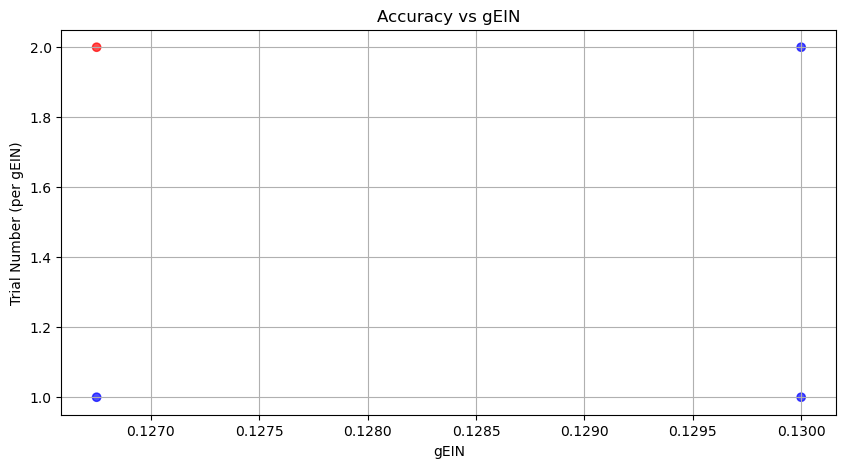

In [3]:
plt.figure(figsize=(10,5))

colors = df["acc"].map({1:"blue", 0:"red"})
#df["trial_index"] = np.arange(len(df))
df["trial_number"] = df.groupby("gEIN").cumcount() + 1
plt.scatter(df["gEIN"], df["trial_number"], c=colors, alpha=0.7)
plt.ylabel("Trial Number (per gEIN)")

#plt.scatter(df["gEEN"], df["trial_index"], c=colors, alpha=0.7)
plt.xlabel("gEIN")
#plt.ylabel("Trial Index")
plt.title("Accuracy vs gEIN")
plt.grid(True)
plt.show()


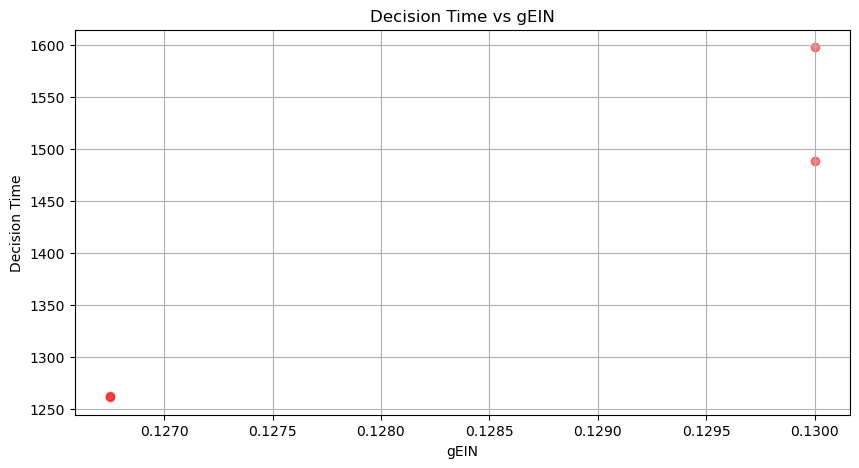

In [4]:
plt.figure(figsize=(10,5))
plt.scatter(df["gEIN"], df["dt"], alpha=0.5, color='red')
plt.xlabel("gEIN")
plt.ylabel("Decision Time")
plt.title("Decision Time vs gEIN")
plt.grid(True)
plt.show()


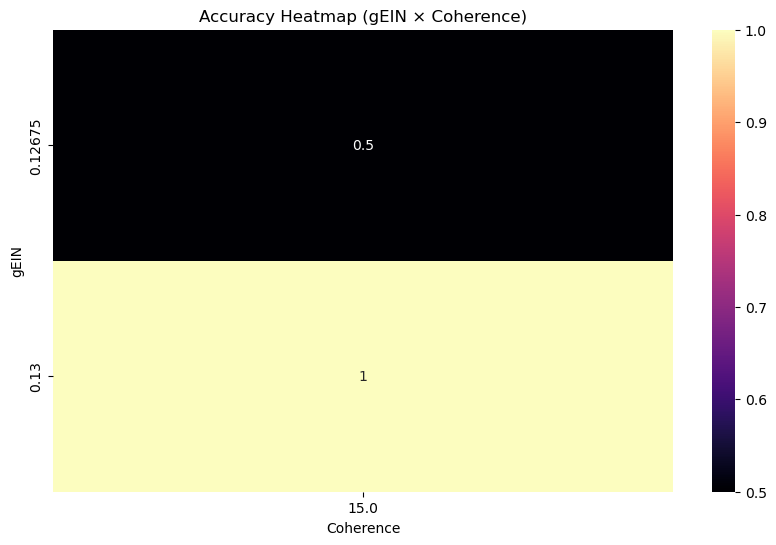

In [5]:
pivot = df.pivot_table(values="acc", index="gEIN", columns="coh", aggfunc="mean")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="magma")
plt.title("Accuracy Heatmap (gEIN × Coherence)")
plt.xlabel("Coherence")
plt.ylabel("gEIN")
plt.show()


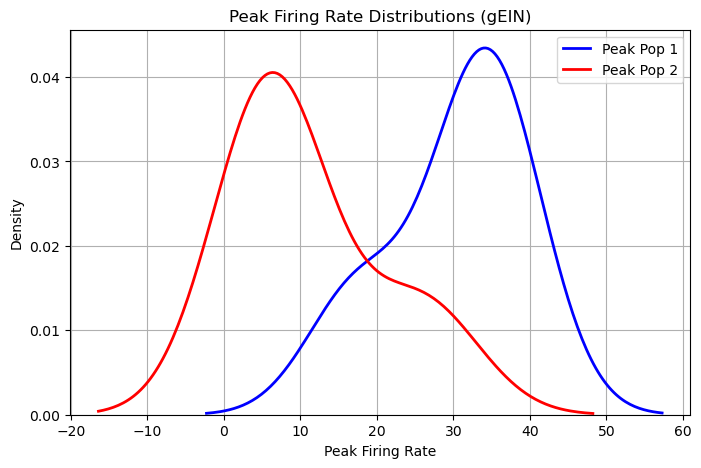

In [6]:
plt.figure(figsize=(8,5))

sns.kdeplot(df["peak1"], label="Peak Pop 1", color="blue", linewidth=2)
sns.kdeplot(df["peak2"], label="Peak Pop 2", color="red", linewidth=2)

plt.xlabel("Peak Firing Rate")
plt.ylabel("Density")
plt.title("Peak Firing Rate Distributions (gEIN)")
plt.legend()
plt.grid(True)
plt.show()


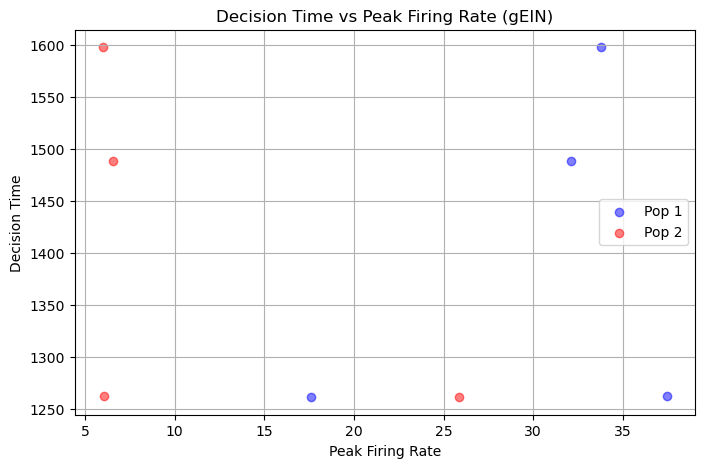

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(df["peak1"], df["dt"], alpha=0.5, label="Pop 1", color="blue")
plt.scatter(df["peak2"], df["dt"], alpha=0.5, label="Pop 2", color="red")

plt.xlabel("Peak Firing Rate")
plt.ylabel("Decision Time")
plt.title("Decision Time vs Peak Firing Rate (gEIN)")
plt.legend()
plt.grid(True)
plt.show()
